# Modelos de Regresión

## 8. Validación Cruzada Temporal — TimeSeriesSplit

Se usa **TimeSeriesSplit con 5 folds** como esquema de validación interna sobre el 75% de entrenamiento. Esto respeta la temporalidad de los datos y simula el escenario real de predicción.

=== Folds de TimeSeriesSplit (Regresión) ===
Fold 1: train=873 | val=870 (1993-08-24 -> 1997-01-30)
Fold 2: train=1743 | val=870 (1997-01-31 -> 2000-07-14)
Fold 3: train=2613 | val=870 (2000-07-17 -> 2004-01-02)
Fold 4: train=3483 | val=870 (2004-01-05 -> 2007-06-19)
Fold 5: train=4353 | val=870 (2007-06-20 -> 2010-12-01)


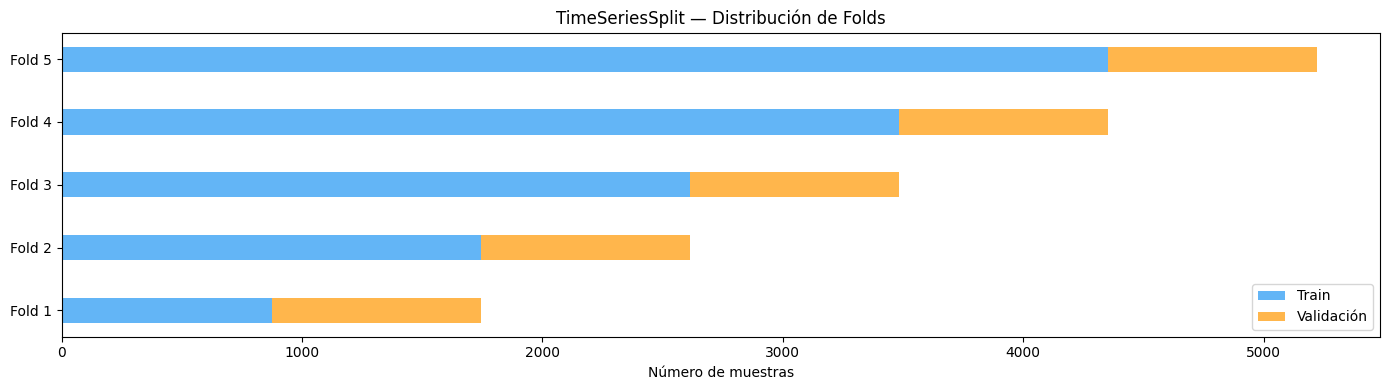

In [36]:
tscv = TimeSeriesSplit(n_splits=5)

print("=== Folds de TimeSeriesSplit (Regresión) ===")
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train_r)):
    print(f"Fold {i+1}: train={len(tr_idx)} | val={len(val_idx)} "
          f"({train_r.iloc[val_idx[0]]['date'].date()} -> {train_r.iloc[val_idx[-1]]['date'].date()})")

# Visualización
fig, ax = plt.subplots(figsize=(14, 4))
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train_r)):
    ax.barh(i, len(tr_idx), left=0, height=0.4, color="#2196F3", alpha=0.7,
            label="Train" if i == 0 else "")
    ax.barh(i, len(val_idx), left=len(tr_idx), height=0.4, color="#FF9800", alpha=0.7,
            label="Validación" if i == 0 else "")
ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_xlabel("Número de muestras")
ax.set_title("TimeSeriesSplit — Distribución de Folds")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Modelos Benchmark — Regresión

Se evalúan 6 modelos encapsulados en **Pipeline** para evitar data leakage:
- Ridge (L2), Lasso (L1), Decision Tree, Random Forest, XGBoost, SVR

Cada modelo se evalúa con TimeSeriesSplit (5 folds) y en el test final (25% holdout).

In [37]:
models_reg = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeRegressor(max_depth=10, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=200, max_depth=10,
                                        random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(n_estimators=200, max_depth=5,
                               learning_rate=0.05, random_state=42,
                               verbosity=0))
    ]),
    "SVR": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=1.0, epsilon=0.001))
    ]),
}

tscv = TimeSeriesSplit(n_splits=5)
results_cv_reg = []
results_test_reg = []
preds_test_reg = {}
residuals_reg = {}

for name, pipe in models_reg.items():
    print(f"\n--- {name} ---")

    # Validación cruzada temporal
    cv_rmse, cv_mae, cv_r2 = [], [], []
    t0 = time.time()
    for tr_idx, val_idx in tscv.split(X_train_r):
        pipe.fit(X_train_r.iloc[tr_idx], y_train_r.iloc[tr_idx])
        yp = pipe.predict(X_train_r.iloc[val_idx])
        cv_rmse.append(np.sqrt(mean_squared_error(y_train_r.iloc[val_idx], yp)))
        cv_mae.append(mean_absolute_error(y_train_r.iloc[val_idx], yp))
        cv_r2.append(r2_score(y_train_r.iloc[val_idx], yp))
    t_cv = time.time() - t0

    results_cv_reg.append({
        "Modelo": name,
        "RMSE_CV": f"{np.mean(cv_rmse):.6f} ± {np.std(cv_rmse):.6f}",
        "MAE_CV": f"{np.mean(cv_mae):.6f} ± {np.std(cv_mae):.6f}",
        "R2_CV": f"{np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}",
        "R2_CV_mean": np.mean(cv_r2),
        "Tiempo_CV": round(t_cv, 2)
    })

    # Test final
    t0 = time.time()
    pipe.fit(X_train_r, y_train_r)
    t_fit = time.time() - t0
    yp_train = pipe.predict(X_train_r)
    yp_test = pipe.predict(X_test_r)
    preds_test_reg[name] = yp_test
    residuals_reg[name] = y_test_r.values - yp_test

    results_test_reg.append({
        "Modelo": name,
        "RMSE_train": np.sqrt(mean_squared_error(y_train_r, yp_train)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test_r, yp_test)),
        "MAE_test": mean_absolute_error(y_test_r, yp_test),
        "R2_train": r2_score(y_train_r, yp_train),
        "R2_test": r2_score(y_test_r, yp_test),
        "Tiempo_fit": round(t_fit, 2)
    })
    print(f"  CV R²: {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f} | Test R²: {r2_score(y_test_r, yp_test):.4f}")


--- Ridge ---
  CV R²: 0.1354 ± 0.2632 | Test R²: 0.0748

--- Lasso ---
  CV R²: 0.0670 ± 0.2809 | Test R²: -0.0133

--- Decision Tree ---
  CV R²: -0.6367 ± 0.6356 | Test R²: -1.4122

--- Random Forest ---
  CV R²: -0.0110 ± 0.3445 | Test R²: -0.2925

--- XGBoost ---
  CV R²: -0.0683 ± 0.3506 | Test R²: -0.2602

--- SVR ---
  CV R²: -0.5681 ± 0.5784 | Test R²: -0.5450


## 10. Tablas Comparativas — Regresión

In [38]:
df_cv_reg = pd.DataFrame(results_cv_reg).sort_values("R2_CV_mean", ascending=False)
print("=== Validación Cruzada Temporal (5-Fold TimeSeriesSplit) ===")
print(df_cv_reg[["Modelo","RMSE_CV","MAE_CV","R2_CV","Tiempo_CV"]].to_string(index=False))

print()
df_test_reg = pd.DataFrame(results_test_reg).sort_values("R2_test", ascending=False)
print("=== Test Final (25% holdout) ===")
print(df_test_reg.to_string(index=False))

=== Validación Cruzada Temporal (5-Fold TimeSeriesSplit) ===
       Modelo             RMSE_CV              MAE_CV            R2_CV  Tiempo_CV
        Ridge 0.009697 ± 0.002941 0.006837 ± 0.001564  0.1354 ± 0.2632       0.15
        Lasso 0.010121 ± 0.003315 0.007179 ± 0.001555  0.0670 ± 0.2809       0.16
Random Forest 0.010340 ± 0.002831 0.007433 ± 0.001403 -0.0110 ± 0.3445      11.35
      XGBoost 0.010698 ± 0.003138 0.007621 ± 0.001599 -0.0683 ± 0.3506       3.84
          SVR 0.012786 ± 0.003409 0.009297 ± 0.001885 -0.5681 ± 0.5784      11.27
Decision Tree 0.012947 ± 0.002727 0.009269 ± 0.001411 -0.6367 ± 0.6356       1.08

=== Test Final (25% holdout) ===
       Modelo  RMSE_train  RMSE_test  MAE_test  R2_train   R2_test  Tiempo_fit
        Ridge    0.009542   0.005978  0.004580  0.442382  0.074751        0.04
        Lasso    0.009779   0.006255  0.005060  0.414365 -0.013291        0.06
      XGBoost    0.005483   0.006976  0.005710  0.815904 -0.260155        0.65
Random Forest  

## 11. Gráficos Real vs Predicho — Regresión

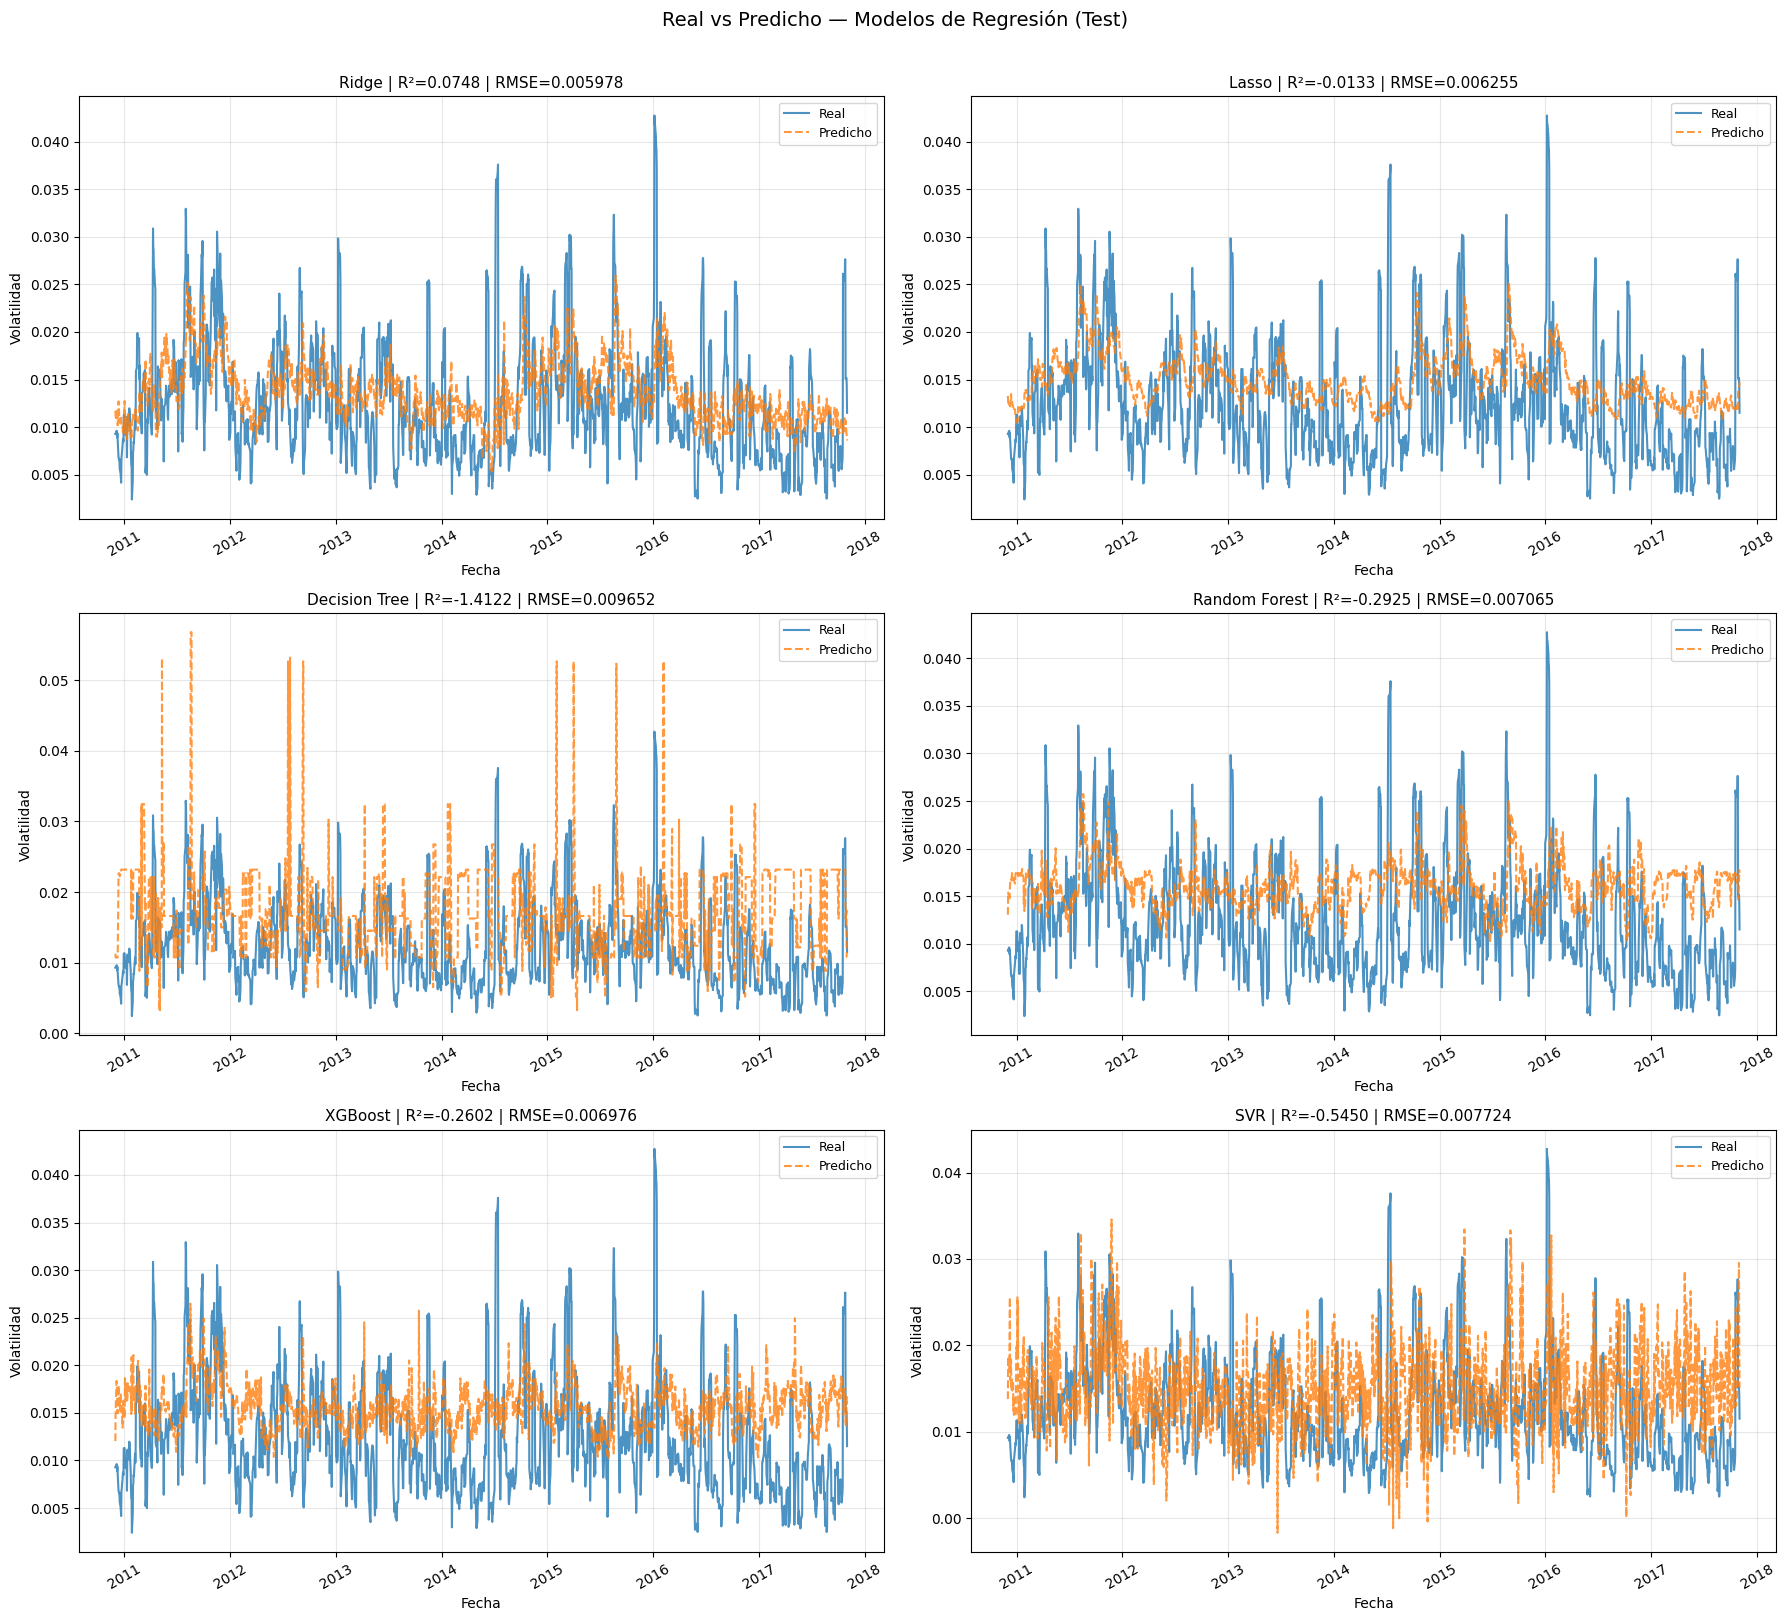

In [39]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, (name, yp) in enumerate(preds_test_reg.items()):
    ax = axes[idx]
    ax.plot(test_r["date"].values, y_test_r.values, label="Real", alpha=0.8)
    ax.plot(test_r["date"].values, yp, label="Predicho", linestyle="--", alpha=0.8)
    r2 = r2_score(y_test_r, yp)
    rmse = np.sqrt(mean_squared_error(y_test_r, yp))
    ax.set_title(f"{name} | R²={r2:.4f} | RMSE={rmse:.6f}", fontsize=11)
    ax.set_xlabel("Fecha"); ax.set_ylabel("Volatilidad")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Real vs Predicho — Modelos de Regresión (Test)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 12. Análisis de Overfitting — Regresión

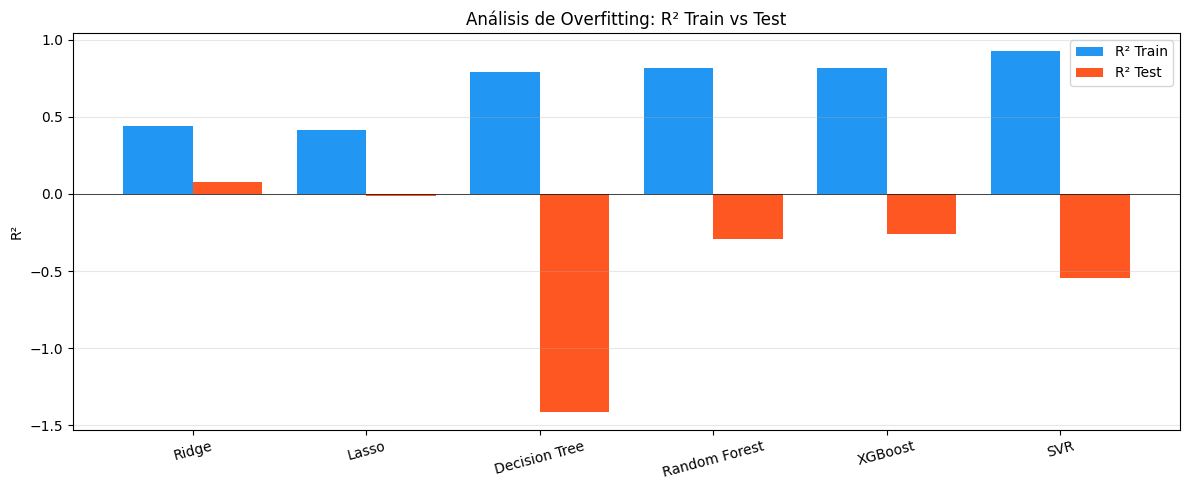

In [40]:
nombres = [r["Modelo"] for r in results_test_reg]
r2_tr = [r["R2_train"] for r in results_test_reg]
r2_te = [r["R2_test"] for r in results_test_reg]

x = np.arange(len(nombres))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, r2_tr, 0.4, label="R² Train", color="#2196F3")
ax.bar(x + 0.2, r2_te, 0.4, label="R² Test", color="#FF5722")
ax.set_xticks(x); ax.set_xticklabels(nombres, rotation=15)
ax.set_ylabel("R²"); ax.set_title("Análisis de Overfitting: R² Train vs Test")
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 13. Análisis de Residuos Completo

Para cada modelo de regresión se evalúa:
- **Test de White:** Homocedasticidad
- **Test de BDS:** Independencia de residuos
- **ACF + Ljung-Box:** Autocorrelación serial
- **Histograma + Jarque-Bera:** Normalidad de residuos

In [41]:
# Función de análisis completo de residuos
def analisis_residuos(nombre, y_true, y_pred, X_test_df):
    residuos = y_true - y_pred
    p_white = np.nan
    p_bds = np.nan
    print(f"\n{'='*60}")
    print(f"ANÁLISIS DE RESIDUOS — {nombre}")
    print(f"{'='*60}")
    print(f"Media: {residuos.mean():.6f}")
    print(f"Std:   {residuos.std():.6f}")

    # --- Test de White (Homocedasticidad) ---
    try:
        X_const = sm.add_constant(X_test_df.values[:, :5])  # primeras 5 features
        white_test = het_white(residuos, X_const)
        print(f"\nTest de White:")
        print(f"  Estadístico: {white_test[0]:.4f}")
        print(f"  p-valor:     {white_test[1]:.4f}")
        print(f"  Interpretación: {'Homocedasticidad (p>{0.05})' if white_test[1] > 0.05 else 'Heterocedasticidad detectada (p<0.05)'}")
    except Exception as e:
        print(f"  Test de White no disponible: {e}")

    # --- Test BDS (Independencia) ---
    try:
        bds_stat, bds_pval = bds(residuos, max_dim=3)
        print(f"\nTest BDS:")
        print(f"  p-valor (dim 2): {bds_pval[0]:.4f}")
        print(f"  Interpretación: {'Residuos independientes (p>0.05)' if bds_pval[0] > 0.05 else 'Dependencia detectada (p<0.05)'}")
    except Exception as e:
        print(f"  Test BDS no disponible: {e}")

    # --- Ljung-Box ---
    try:
        lb = acorr_ljungbox(residuos, lags=[10, 20], return_df=True)
        print(f"\nTest Ljung-Box:")
        print(lb.to_string())
    except Exception as e:
        print(f"  Ljung-Box no disponible: {e}")

    # --- Jarque-Bera (Normalidad) ---
    try:
        jb_stat, jb_pval, skew, kurt = jarque_bera(residuos)
        print(f"\nTest Jarque-Bera (Normalidad):")
        print(f"  Estadístico: {jb_stat:.4f}")
        print(f"  p-valor:     {jb_pval:.4f}")
        print(f"  Skewness:    {skew:.4f}")
        print(f"  Kurtosis:    {kurt:.4f}")
        print(f"  Interpretación: {'Distribución normal (p>0.05)' if jb_pval > 0.05 else 'No normal (p<0.05)'}")
    except Exception as e:
        print(f"  Jarque-Bera no disponible: {e}")

    # --- Gráficos ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Histograma
    axes[0].hist(residuos, bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title(f"{nombre} — Histograma de residuos")
    axes[0].set_xlabel("Residuo"); axes[0].set_ylabel("Frecuencia")

    # ACF
    acf_vals = acf(residuos, nlags=30)
    axes[1].bar(range(len(acf_vals)), acf_vals, color="#2196F3", alpha=0.7)
    axes[1].axhline(y=1.96/np.sqrt(len(residuos)), color='red', linestyle='--', alpha=0.5)
    axes[1].axhline(y=-1.96/np.sqrt(len(residuos)), color='red', linestyle='--', alpha=0.5)
    axes[1].set_title(f"{nombre} — ACF de residuos")
    axes[1].set_xlabel("Lag"); axes[1].set_ylabel("Autocorrelación")

    # Residuos vs predichos
    axes[2].scatter(y_pred, residuos, alpha=0.3, s=10)
    axes[2].axhline(y=0, color='red', linewidth=1)
    axes[2].set_title(f"{nombre} — Residuos vs Predichos")
    axes[2].set_xlabel("Predicho"); axes[2].set_ylabel("Residuo")

    plt.tight_layout()
    plt.show()

    return {"Modelo": nombre}


ANÁLISIS DE RESIDUOS — Ridge
Media: -0.000940
Std:   0.005903

Test de White:
  Estadístico: 16.0955
  p-valor:     0.7107
  Interpretación: Homocedasticidad (p>{0.05})

Test BDS:
  p-valor (dim 2): 0.0000
  Interpretación: Dependencia detectada (p<0.05)

Test Ljung-Box:
        lb_stat  lb_pvalue
10  2737.860062        0.0
20  2856.460772        0.0

Test Jarque-Bera (Normalidad):
  Estadístico: 1110.6511
  p-valor:     0.0000
  Skewness:    1.3276
  Kurtosis:    5.8726
  Interpretación: No normal (p<0.05)


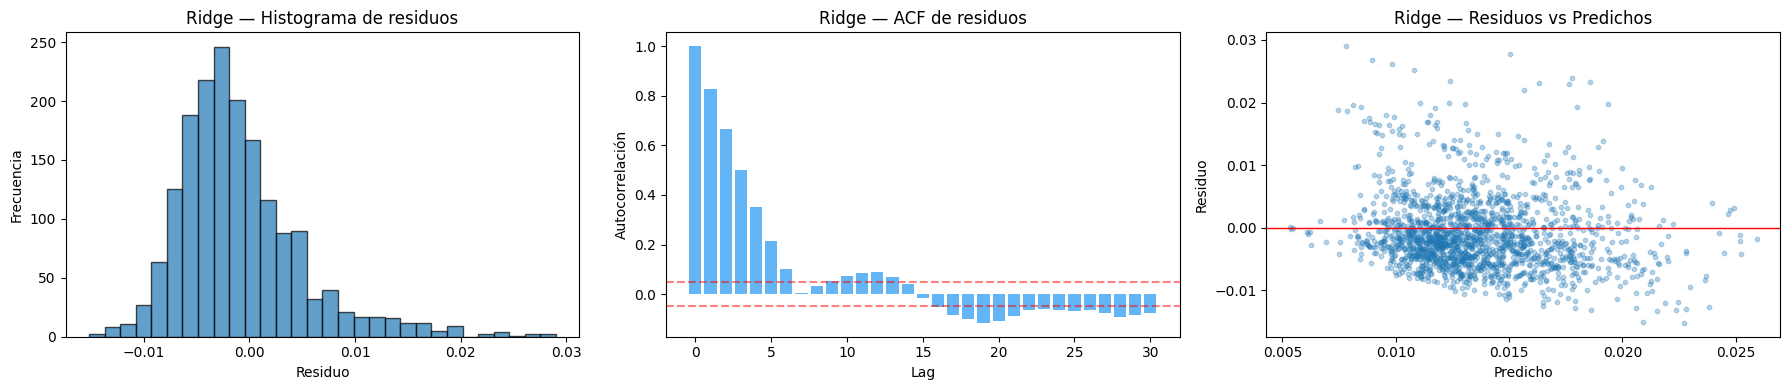


ANÁLISIS DE RESIDUOS — Lasso
Media: -0.002231
Std:   0.005844

Test de White:
  Estadístico: 25.6449
  p-valor:     0.1779
  Interpretación: Homocedasticidad (p>{0.05})

Test BDS:
  p-valor (dim 2): 0.0000
  Interpretación: Dependencia detectada (p<0.05)

Test Ljung-Box:
        lb_stat  lb_pvalue
10  2735.183158        0.0
20  2824.381820        0.0

Test Jarque-Bera (Normalidad):
  Estadístico: 1322.8512
  p-valor:     0.0000
  Skewness:    1.4130
  Kurtosis:    6.1999
  Interpretación: No normal (p<0.05)


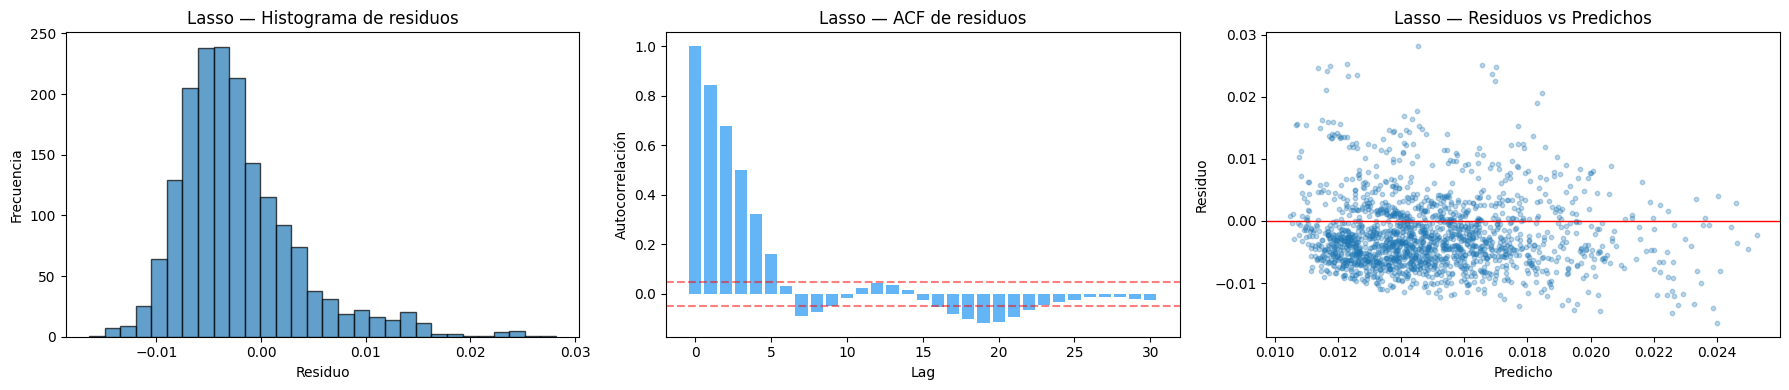


ANÁLISIS DE RESIDUOS — Decision Tree
Media: -0.004461
Std:   0.008559

Test de White:
  Estadístico: 47.9978
  p-valor:     0.0004
  Interpretación: Heterocedasticidad detectada (p<0.05)

Test BDS:
  p-valor (dim 2): 0.0000
  Interpretación: Dependencia detectada (p<0.05)

Test Ljung-Box:
        lb_stat  lb_pvalue
10  2845.552257        0.0
20  3440.142546        0.0

Test Jarque-Bera (Normalidad):
  Estadístico: 340.7462
  p-valor:     0.0000
  Skewness:    -0.1914
  Kurtosis:    5.1326
  Interpretación: No normal (p<0.05)


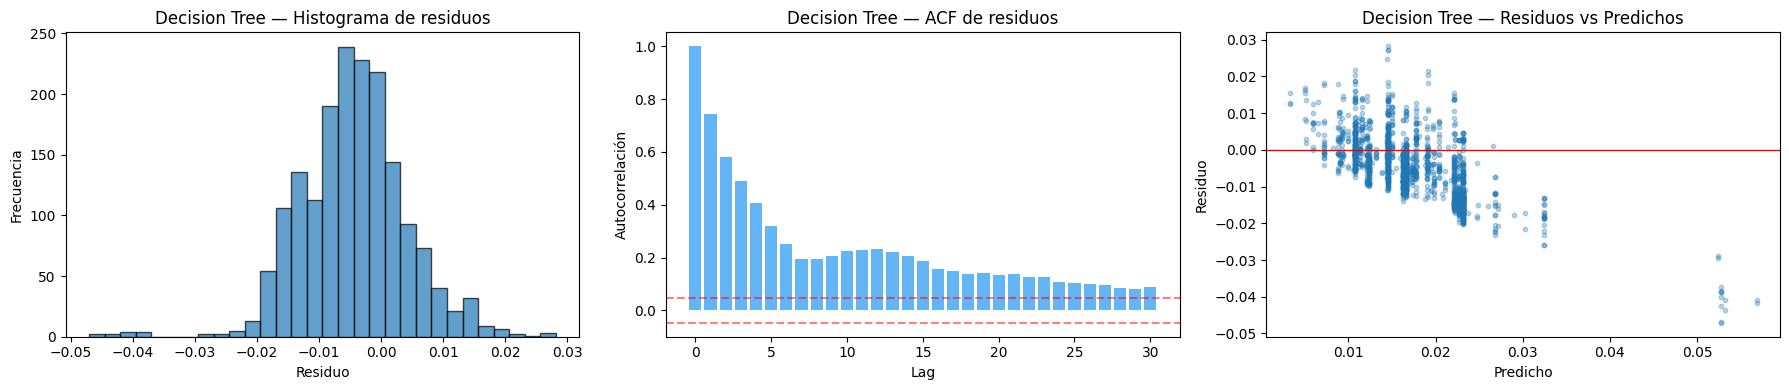


ANÁLISIS DE RESIDUOS — Random Forest
Media: -0.003278
Std:   0.006258

Test de White:
  Estadístico: 19.6124
  p-valor:     0.4824
  Interpretación: Homocedasticidad (p>{0.05})

Test BDS:
  p-valor (dim 2): 0.0000
  Interpretación: Dependencia detectada (p<0.05)

Test Ljung-Box:
        lb_stat  lb_pvalue
10  3459.167246        0.0
20  3799.971117        0.0

Test Jarque-Bera (Normalidad):
  Estadístico: 505.5251
  p-valor:     0.0000
  Skewness:    1.0301
  Kurtosis:    4.6493
  Interpretación: No normal (p<0.05)


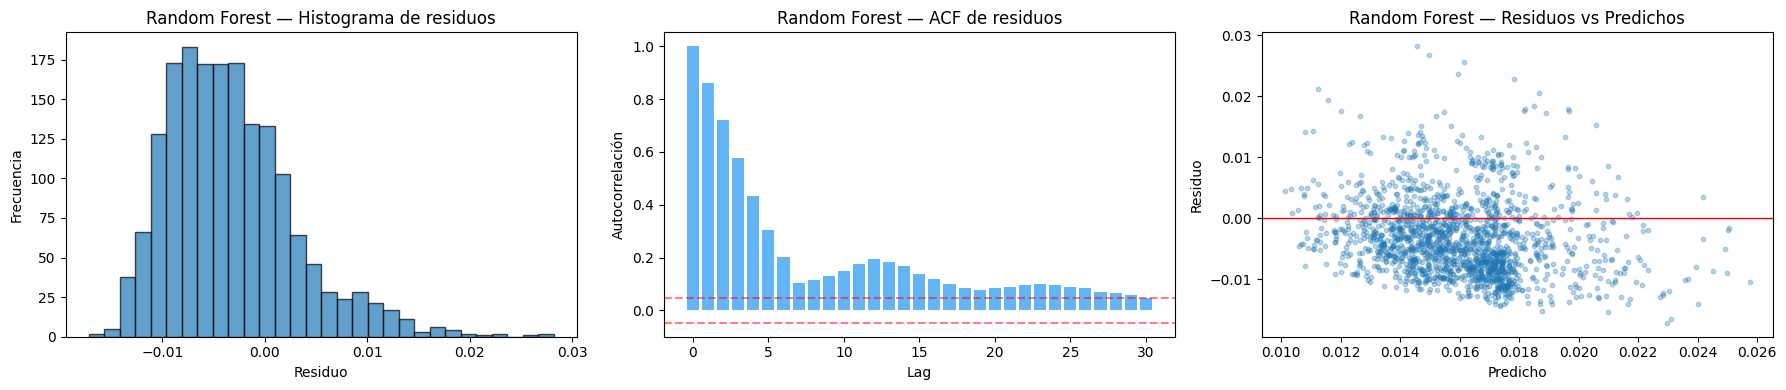


ANÁLISIS DE RESIDUOS — XGBoost
Media: -0.002885
Std:   0.006352

Test de White:
  Estadístico: 15.3685
  p-valor:     0.7549
  Interpretación: Homocedasticidad (p>{0.05})

Test BDS:
  p-valor (dim 2): 0.0000
  Interpretación: Dependencia detectada (p<0.05)

Test Ljung-Box:
        lb_stat  lb_pvalue
10  3327.328563        0.0
20  3785.590562        0.0

Test Jarque-Bera (Normalidad):
  Estadístico: 540.3121
  p-valor:     0.0000
  Skewness:    1.0210
  Kurtosis:    4.8095
  Interpretación: No normal (p<0.05)


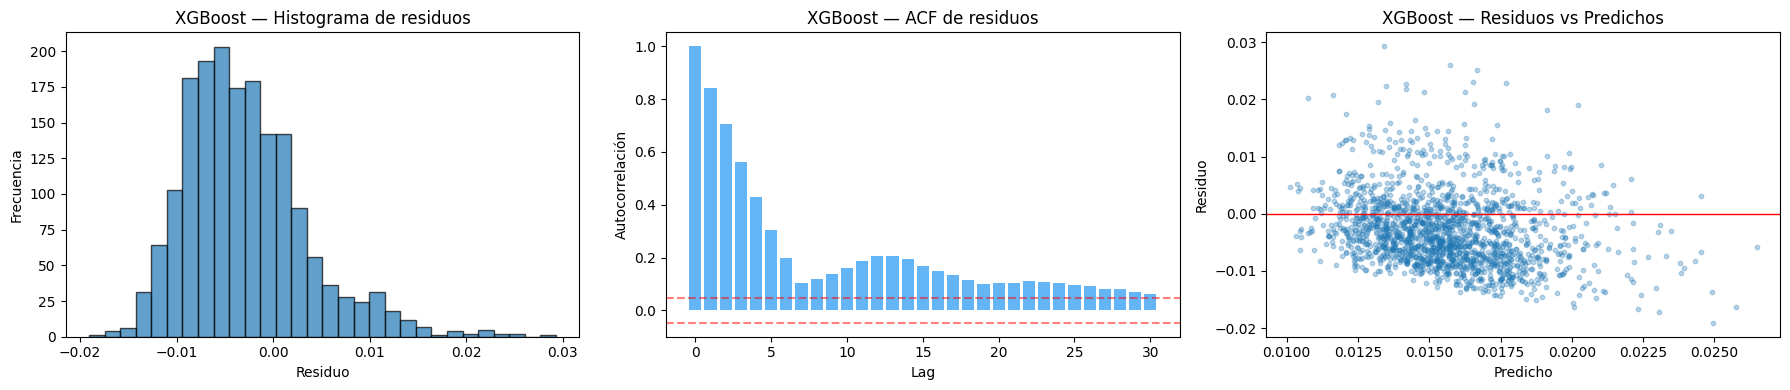


ANÁLISIS DE RESIDUOS — SVR
Media: -0.002175
Std:   0.007412

Test de White:
  Estadístico: 19.4298
  p-valor:     0.4941
  Interpretación: Homocedasticidad (p>{0.05})

Test BDS:
  p-valor (dim 2): 0.0000
  Interpretación: Dependencia detectada (p<0.05)

Test Ljung-Box:
        lb_stat  lb_pvalue
10  2218.876660        0.0
20  2497.782966        0.0

Test Jarque-Bera (Normalidad):
  Estadístico: 215.0171
  p-valor:     0.0000
  Skewness:    0.6823
  Kurtosis:    4.0490
  Interpretación: No normal (p<0.05)


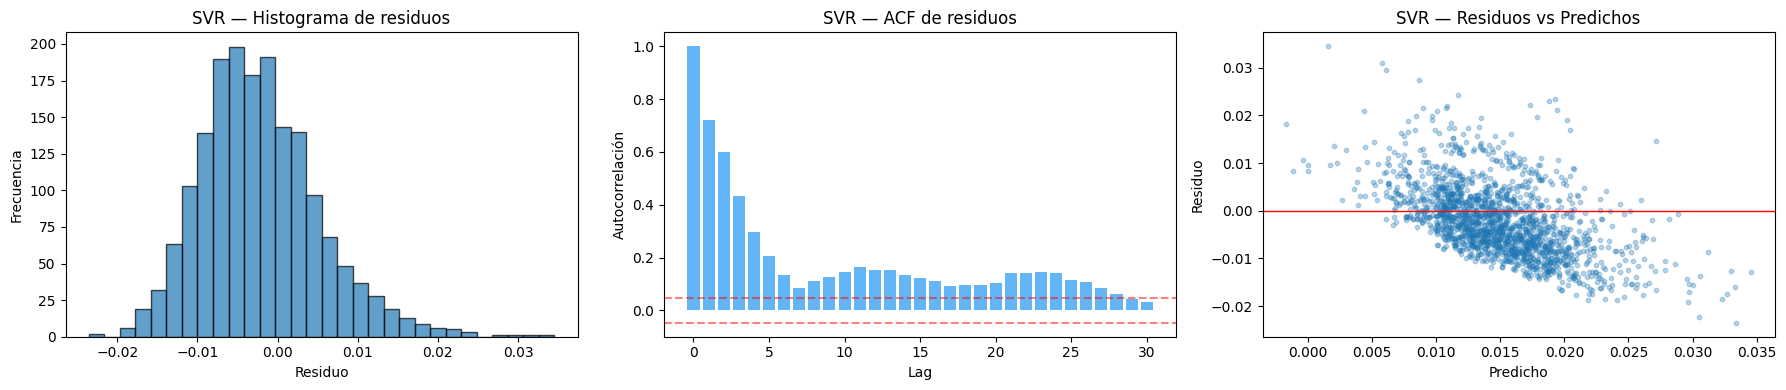

In [42]:
# Aplicar análisis de residuos a todos los modelos de regresión
residuos_stats = []
imputer = SimpleImputer(strategy="median")
X_test_imputed = pd.DataFrame(imputer.fit_transform(X_test_r), columns=feature_cols)

for name, yp in preds_test_reg.items():
    stats_r = analisis_residuos(name, y_test_r.values, yp, X_test_imputed)
    residuos_stats.append(stats_r)